# 기말고사 문제 3 — Diamonds 분류 분석  〔배포용〕

> 배점: **25점** (Part C 15 + Part D 10) + Part E 보너스  ·  Part A·B(EDA/전처리)는 제공 코드


---

## 📌 시험 안내

### 데이터
- **출처**: seaborn 내장 데이터셋 (`seaborn.load_dataset('diamonds')`)
- **샘플**: 53,940개
- **타겟**: `cut` (5클래스 분류: Fair / Good / Very Good / Premium / Ideal)
- **특성**:
  - 수치형: carat, depth, table, price, x, y, z
  - 범주형: color (7등급), clarity (8등급)



In [1]:
STUDENT_ID = "3085"   # ← 본인 학번 마지막 4자리로 변경
SEED = int(STUDENT_ID)

assert STUDENT_ID != "0000", "학번을 입력하세요!"
print(f'학번(끝4자리): {STUDENT_ID}, SEED: {SEED}')

학번(끝4자리): 3085, SEED: 3085


## 환경 준비

필요한 라이브러리를 import하고 seed를 고정하세요.
(seaborn, sklearn.metrics 등 분류에 필요한 모듈도 포함)

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from keras import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Activation
from keras.regularizers import l2
from keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

# 재현성: 학번 기반 SEED로 고정 (numpy + 현재 keras 백엔드 동시 고정)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

print('Keras  :', keras.__version__, '| backend:', keras.backend.backend())
print('pandas :', pd.__version__)

I0000 00:00:1781880128.169287  488215 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781880128.169893  488215 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1781880130.493916  488215 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781880130.494394  488215 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Keras  : 3.14.1 | backend: tensorflow
pandas : 3.0.2


---
# Part A. EDA + 클래스 분포 (제공 코드)

## A1. 데이터 로드 및 기본 정보 출력

- `seaborn.load_dataset('diamonds')`로 로드
- 데이터 shape, 수치형/범주형 컬럼 목록, 결측치 개수, 기본 통계 출력



In [3]:
df = sns.load_dataset('diamonds')
print(f'Shape: {df.shape}')
print(f'\n수치형 컬럼: {df.select_dtypes(include="number").columns.tolist()}')
print(f'범주형 컬럼: {df.select_dtypes(include="category").columns.tolist()}')
print(f'\n결측치: {df.isnull().sum().sum()}')
print(f'\n기본 통계:')
print(df.describe())

Shape: (53940, 10)

수치형 컬럼: ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
범주형 컬럼: ['cut', 'color', 'clarity']

결측치: 0

기본 통계:
              carat         depth         table         price             x  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184   3932.799722      5.731157   
std        0.474011      1.432621      2.234491   3989.439738      1.121761   
min        0.200000     43.000000     43.000000    326.000000      0.000000   
25%        0.400000     61.000000     56.000000    950.000000      4.710000   
50%        0.700000     61.800000     57.000000   2401.000000      5.700000   
75%        1.040000     62.500000     59.000000   5324.250000      6.540000   
max        5.010000     79.000000     95.000000  18823.000000     10.740000   

                  y             z  
count  53940.000000  53940.000000  
mean       5.734526      3.538734  
std        1.142135      0.705699  
min        0

## A2. 타겟 변수(cut) 클래스 분포

- 각 클래스 개수와 비율을 출력
- 막대 그래프로 시각화 (제목/축 라벨 포함)
- 클래스 불균형 비율 계산 (최대 클래스 / 최소 클래스)

cut (타겟) 분포:
cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

비율:
cut
Ideal        0.400
Premium      0.256
Very Good    0.224
Good         0.091
Fair         0.030
Name: proportion, dtype: float64


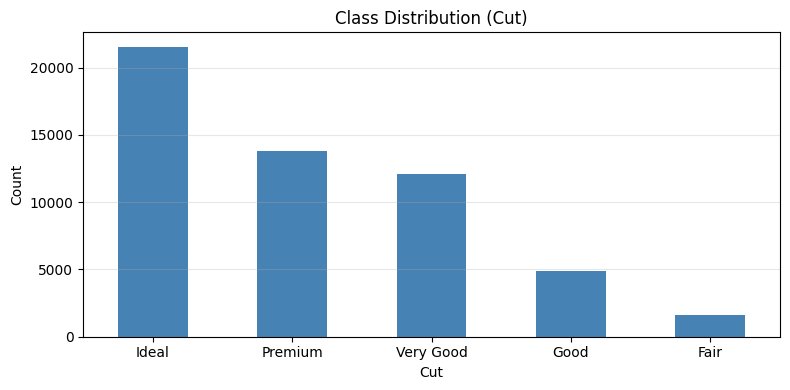


클래스 불균형 비율 (최대/최소): 13.4배


In [4]:
print('cut (타겟) 분포:')
print(df['cut'].value_counts())
print()
print('비율:')
print(df['cut'].value_counts(normalize=True).round(3))

# 시각화
plt.figure(figsize=(8, 4))
df['cut'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Class Distribution (Cut)')
plt.xlabel('Cut')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 클래스 불균형 비율 계산
imbalance_ratio = df['cut'].value_counts().max() / df['cut'].value_counts().min()
print(f'\n클래스 불균형 비율 (최대/최소): {imbalance_ratio:.1f}배')

## A3. 이상치 탐지 및 처리

데이터의 `x`, `y`, `z` (다이아몬드 크기) 컬럼에 *0값*이 존재할 수 있습니다.
이는 측정 오류로 추정됩니다.

- 각 컬럼별 0값 개수 출력
- 이상치를 처리한 후 데이터 shape 출력



In [5]:
# x, y, z (다이아몬드 크기)에 0값(이상치) 존재 여부 확인
for col in ['x', 'y', 'z']:
    zeros = (df[col] == 0).sum()
    print(f'{col}: 0 values = {zeros}')

# 이상치 처리: x, y, z 중 0인 행 제거
df_clean = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)].copy()
print(f'\n이상치 제거 후 shape: {df_clean.shape}')

x: 0 values = 8
y: 0 values = 7
z: 0 values = 20



이상치 제거 후 shape: (53920, 10)


---
# Part B. 범주형 인코딩 전처리 (제공 코드)

## B1. Ordinal Encoding (color, clarity)

`color`와 `clarity`는 **순서가 있는** 범주형 변수입니다:
- color: D(최고) → J(최하)
- clarity: IF(최고) → I1(최하)

**필요사항**:
- 순서를 보존하는 Ordinal Encoding 적용
- 인코딩 후 결과 검증 (예: 등급별 매핑 출력)


In [6]:
# 순서 정의 (등급 좋은 순으로 높은 숫자)
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']           # D가 최고
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']  # IF가 최고

color_map = {c: i for i, c in enumerate(color_order)}
clarity_map = {c: i for i, c in enumerate(clarity_order)}

df_clean['color_ord']   = df_clean['color'].map(color_map)
df_clean['clarity_ord'] = df_clean['clarity'].map(clarity_map)

print('color 인코딩 확인:')
print(df_clean[['color', 'color_ord']].drop_duplicates().sort_values('color_ord'))
print()
print('clarity 인코딩 확인:')
print(df_clean[['clarity', 'clarity_ord']].drop_duplicates().sort_values('clarity_ord'))

color 인코딩 확인:
   color color_ord
28     D         6
0      E         5
12     F         4
25     G         3
7      H         2
3      I         1
4      J         0

clarity 인코딩 확인:
    clarity clarity_ord
229      IF           7
6      VVS1           6
5      VVS2           5
2       VS1           4
3       VS2           3
1       SI1           2
0       SI2           1
15       I1           0


## B2. 타겟 인코딩

- `cut` 타겟을 정수로 인코딩 (Fair=0, Good=1, Very Good=2, Premium=3, Ideal=4)

**출력**:
- 인코딩 후 결과 검증 (예: 클래스별 매핑 출력)

In [7]:
# 타겟 인코딩
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
cut_map = {c: i for i, c in enumerate(cut_order)}

df_clean['cut_label'] = df_clean['cut'].map(cut_map)

print('cut 인코딩:')
print(df_clean[['cut', 'cut_label']].drop_duplicates().sort_values('cut_label'))

cut 인코딩:
         cut cut_label
0      Ideal         4
1    Premium         3
5  Very Good         2
2       Good         1
8       Fair         0


## B3. Feature 선택 + 3분할 + 정규화

- Feature 선택 (수치형 + 인코딩한 범주형)
- 3분할 (60/20/20)
- **반드시 `stratify=y` 사용** (클래스 비율 유지)
- StandardScaler로 정규화

> 💡 **stratify=y**: 클래스 분포가 불균형하므로 분할 시 비율 유지 필수

**출력**:
- X_train, X_val, X_test shape
- 분할 후 각 클래스 비율이 유지되는지 확인 (예: train의 y_train 분포)

In [8]:
# Feature 선택
feature_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z',
                'color_ord', 'clarity_ord']
X = df_clean[feature_cols].values.astype(np.float32)
y = df_clean['cut_label'].values.astype(np.int32)

print(f'X: {X.shape}, y: {y.shape}')
print(f'클래스 수: {len(np.unique(y))}')

# 3분할 (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y  # 클래스 비율 유지
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp
)

# 정규화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f'\nTrain: {X_train.shape}')
print(f'Val  : {X_val.shape}')
print(f'Test : {X_test.shape}')

# 분할 후 클래스 비율 유지 확인
print('\n[클래스 비율 유지 확인]')
for name, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    ratio = pd.Series(yy).value_counts(normalize=True).sort_index().round(3).tolist()
    print(f'  {name:5s}: {ratio}')

X: (53920, 9), y: (53920,)
클래스 수: 5

Train: (32352, 9)
Val  : (10784, 9)
Test : (10784, 9)

[클래스 비율 유지 확인]
  train: [0.03, 0.091, 0.224, 0.256, 0.4]
  val  : [0.03, 0.091, 0.224, 0.256, 0.4]
  test : [0.03, 0.091, 0.224, 0.256, 0.4]


---
# Part C. 분류 모델 구축 (15점)

## C0. (추가입니다._EDA)

## C0. 제공 split 보존 EDA와 모델링 결정

이 섹션은 A/B 제공 전처리 코드를 수정하지 않고, 제공된 `X_train`, `X_val` 뒤의 원본 행만 복원해 모델 설계 근거를 설명한다. `X_test`는 Part D 전까지 열지 않는다.

핵심 모델링 결정은 다음과 같다.

- Target은 `Fair=0`부터 `Ideal=4`까지의 5-class ordinal multiclass 문제다. 모델은 시험 요구에 맞게 softmax와 sparse categorical cross-entropy를 사용하고, 순서형 오차는 `ordinal_mae`로 보조 확인한다.
- 직접 geometry 신호는 `table`, `depth`, `xy_ratio`, `z_to_xy_mean`이다. 이 변수들은 cut과 연결되는 비율/형태 정보를 담는다.
- `carat`, `x`, `y`, `z`, `volume`, `price`는 강한 size-price 중복 축을 형성한다.
- `Fair`, `Good`은 소수 클래스이므로 accuracy만 보지 않고 macro-F1, balanced accuracy, class별 recall, ordinal MAE를 함께 본다.
- 최종 mandatory 모델은 test를 보기 전에 validation metric 기준으로 선택한다.


In [9]:
print('=== C0-1. Rebuild split metadata without opening test EDA ===')

from IPython.display import display, Markdown
from scipy.stats import spearmanr, kruskal, chi2_contingency
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
)
from sklearn.utils.class_weight import compute_class_weight

# Recreate only positional indices using the exact B3 split logic.
# The provided X_train, X_val, X_test, y_train, y_val, y_test arrays are not changed.
idx_all = np.arange(len(df_clean), dtype=np.int64)

idx_temp, idx_test_locked, y_temp_idx, y_test_idx_locked = train_test_split(
    idx_all,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

idx_train, idx_val, y_train_idx, y_val_idx = train_test_split(
    idx_temp,
    y_temp_idx,
    test_size=0.25,
    random_state=SEED,
    stratify=y_temp_idx,
)

train_meta = df_clean.iloc[idx_train].copy()
val_meta = df_clean.iloc[idx_val].copy()

train_X_raw_recovered = scaler.inverse_transform(X_train)
val_X_raw_recovered = scaler.inverse_transform(X_val)

train_alignment = (
    np.array_equal(y_train_idx.astype(np.int32), y_train)
    and np.array_equal(train_meta['cut_label'].to_numpy(np.int32), y_train)
    and np.allclose(
        train_X_raw_recovered,
        train_meta[feature_cols].to_numpy(np.float32),
        rtol=1e-5,
        atol=1e-3,
    )
)

val_alignment = (
    np.array_equal(y_val_idx.astype(np.int32), y_val)
    and np.array_equal(val_meta['cut_label'].to_numpy(np.int32), y_val)
    and np.allclose(
        val_X_raw_recovered,
        val_meta[feature_cols].to_numpy(np.float32),
        rtol=1e-5,
        atol=1e-3,
    )
)

assert train_alignment, 'train_meta is not aligned with provided X_train/y_train.'
assert val_alignment, 'val_meta is not aligned with provided X_val/y_val.'

print('train alignment:', train_alignment, '| shape:', train_meta.shape)
print('val alignment  :', val_alignment, '| shape:', val_meta.shape)
print('test           : locked until Part D')


def add_diagnostic_features(frame):
    """Create diagnostic-only geometry/price features without changing mandatory X."""
    out = frame.copy()
    xy_mean = (out['x'] + out['y']) / 2.0
    out['volume'] = out['x'] * out['y'] * out['z']
    out['xy_ratio'] = out['x'] / out['y']
    out['z_to_xy_mean'] = out['z'] / xy_mean
    out['price_per_carat'] = out['price'] / out['carat']
    return out


train_eda = add_diagnostic_features(train_meta)
val_eda = add_diagnostic_features(val_meta)

print('train_eda shape:', train_eda.shape)
print('val_eda shape  :', val_eda.shape)


=== C0-1. Rebuild split metadata without opening test EDA ===
train alignment: True | shape: (32352, 13)
val alignment  : True | shape: (10784, 13)
test           : locked until Part D
train_eda shape: (32352, 17)
val_eda shape  : (10784, 17)


=== C0-2. Train/validation class balance ===


,class_id,class_name,train_count,train_ratio,val_count,val_ratio
0,0,Fair,965,0.029828,322,0.029859
1,1,Good,2942,0.090937,980,0.090875
2,2,Very Good,7249,0.224067,2416,0.224036
3,3,Premium,8268,0.255564,2756,0.255564
4,4,Ideal,12928,0.399604,4310,0.399666


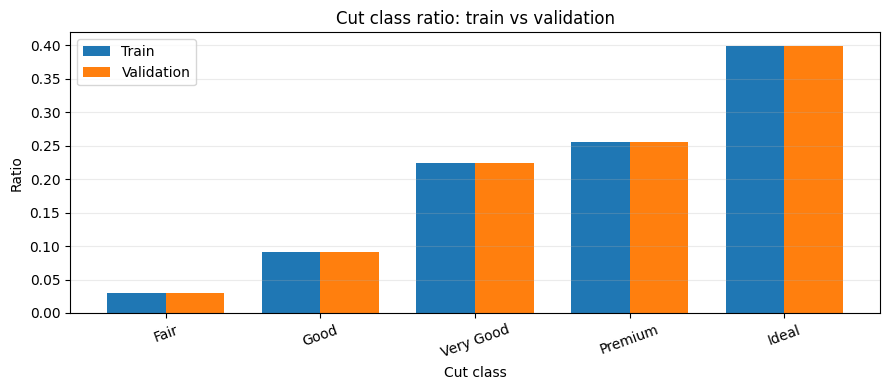

Candidate class weights from train split:
  Fair       (0): 6.7051
  Good       (1): 2.1993
  Very Good  (2): 0.8926
  Premium    (3): 0.7826
  Ideal      (4): 0.5005

Modeling implication:
- Fair/Good are minority classes, so accuracy alone is not enough.
- C1/C2 remain unweighted for the mandatory controlled comparison.
- Validation macro-F1 is the primary selection metric; ordinal MAE is a supplementary error-distance check.
- class_weight is isolated as the optional Part E experiment.


In [10]:
print('=== C0-2. Train/validation class balance ===')

class_ids = np.arange(len(cut_order))

train_counts = pd.Series(y_train).value_counts().reindex(class_ids, fill_value=0)
val_counts = pd.Series(y_val).value_counts().reindex(class_ids, fill_value=0)

split_distribution = pd.DataFrame({
    'class_id': class_ids,
    'class_name': cut_order,
    'train_count': train_counts.to_numpy(),
    'train_ratio': (train_counts / len(y_train)).to_numpy(),
    'val_count': val_counts.to_numpy(),
    'val_ratio': (val_counts / len(y_val)).to_numpy(),
})

display(split_distribution)

fig, ax = plt.subplots(figsize=(9, 4))
x_pos = np.arange(len(cut_order))
width = 0.38
ax.bar(x_pos - width / 2, split_distribution['train_ratio'], width=width, label='Train')
ax.bar(x_pos + width / 2, split_distribution['val_ratio'], width=width, label='Validation')
ax.set_title('Cut class ratio: train vs validation')
ax.set_xlabel('Cut class')
ax.set_ylabel('Ratio')
ax.set_xticks(x_pos)
ax.set_xticklabels(cut_order, rotation=20)
ax.legend()
ax.grid(alpha=0.25, axis='y')
plt.tight_layout()
plt.show()

balanced_weights = compute_class_weight(
    class_weight='balanced',
    classes=class_ids,
    y=y_train,
)

class_weight_dict = {
    int(c): float(w)
    for c, w in zip(class_ids, balanced_weights)
}

print('Candidate class weights from train split:')
for class_id, class_name in enumerate(cut_order):
    print(f'  {class_name:10s} ({class_id}): {class_weight_dict[class_id]:.4f}')

print('\nModeling implication:')
print('- Fair/Good are minority classes, so accuracy alone is not enough.')
print('- C1/C2 remain unweighted for the mandatory controlled comparison.')
print('- Validation macro-F1 is the primary selection metric; ordinal MAE is a supplementary error-distance check.')
print('- class_weight is isolated as the optional Part E experiment.')


=== C0-3. Train-only numeric evidence for cut separation ===


,feature,spearman_corr,spearman_p_value,kruskal_stat,kruskal_p_value,epsilon_sq_effect
0,table,-0.474184,0.000000e+00,12377.980218,0.000000e+00,0.382539
1,xy_ratio,0.019192,5.561949e-04,6605.139958,0.000000e+00,0.204073
2,depth,-0.206900,9.862443e-310,3551.828548,0.000000e+00,0.109680
3,z_to_xy_mean,-0.207077,2.860125e-310,3526.733699,0.000000e+00,0.108904
4,z,-0.149802,1.087375e-161,1148.984762,1.824604e-247,0.035397
5,carat,-0.139452,3.535842e-140,1127.456812,8.466494e-243,0.034731
6,x,-0.125211,3.497005e-113,1113.486900,9.032882e-240,0.034300
7,volume,-0.127411,3.706139e-117,988.062660,1.378962e-212,0.030422
8,y,-0.126108,8.556363e-115,932.112425,1.835388e-200,0.028692
9,price,-0.094100,1.559135e-64,614.333321,1.224616e-131,0.018868


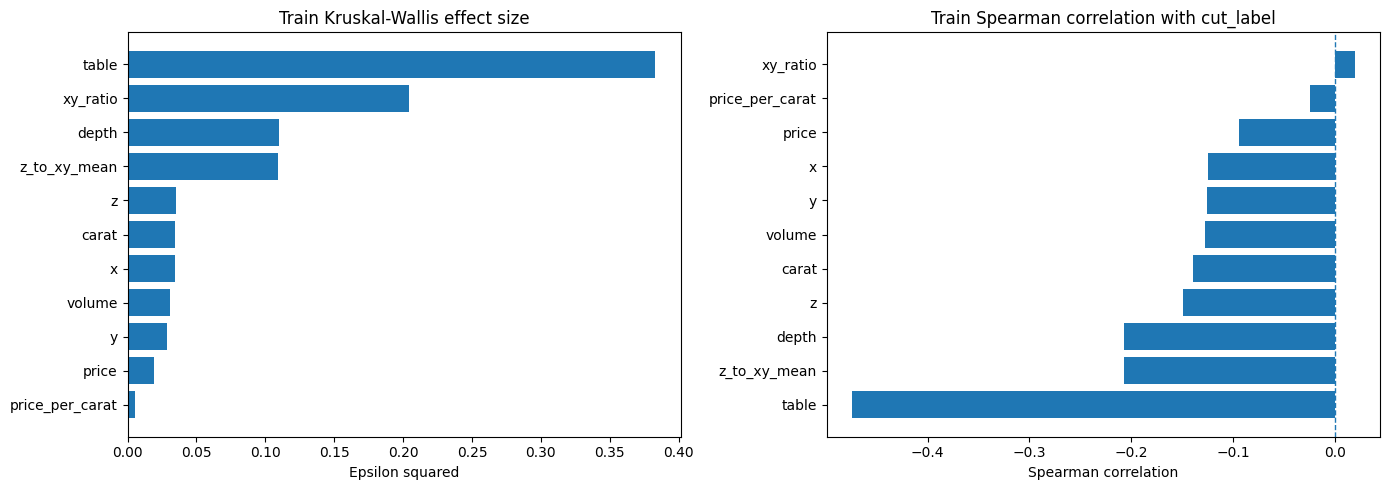


**EDA 해석.** `table`은 train 기준에서 가장 강한 geometry 신호다. `xy_ratio`, `depth`, `z_to_xy_mean`도 단조 상관이 아주 크지 않더라도 class별 분포를 분리한다. 반면 `carat/x/y/z/volume/price`는 독립적인 cut 원인이라기보다 중복된 size-price 축으로 해석한다.

**상위 numeric 근거:** `table, xy_ratio, depth, z_to_xy_mean, z, carat`.


In [11]:
print('=== C0-3. Train-only numeric evidence for cut separation ===')

numeric_eda_cols = [
    'carat', 'depth', 'table', 'price', 'x', 'y', 'z',
    'volume', 'xy_ratio', 'z_to_xy_mean', 'price_per_carat',
]

numeric_rows = []

for col in numeric_eda_cols:
    rho, spearman_p = spearmanr(train_eda[col], train_eda['cut_label'])

    groups = [
        train_eda.loc[train_eda['cut_label'] == class_id, col].to_numpy()
        for class_id in class_ids
    ]

    h_stat, kw_p = kruskal(*groups)

    n = len(train_eda)
    k = len(class_ids)
    epsilon_sq = max(0.0, (h_stat - k + 1) / (n - k))

    numeric_rows.append({
        'feature': col,
        'spearman_corr': rho,
        'spearman_p_value': spearman_p,
        'kruskal_stat': h_stat,
        'kruskal_p_value': kw_p,
        'epsilon_sq_effect': epsilon_sq,
    })

numeric_train_result = (
    pd.DataFrame(numeric_rows)
    .sort_values(['epsilon_sq_effect', 'feature'], ascending=[False, True])
    .reset_index(drop=True)
)

top_numeric_features = numeric_train_result.head(6)['feature'].tolist()
display(numeric_train_result)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_effect = numeric_train_result.sort_values('epsilon_sq_effect')
axes[0].barh(plot_effect['feature'], plot_effect['epsilon_sq_effect'])
axes[0].set_title('Train Kruskal-Wallis effect size')
axes[0].set_xlabel('Epsilon squared')

plot_rho = numeric_train_result.sort_values('spearman_corr')
axes[1].barh(plot_rho['feature'], plot_rho['spearman_corr'])
axes[1].axvline(0, linestyle='--', linewidth=1)
axes[1].set_title('Train Spearman correlation with cut_label')
axes[1].set_xlabel('Spearman correlation')

plt.tight_layout()
plt.show()

display(Markdown(f"""
**EDA 해석.** `table`은 train 기준에서 가장 강한 geometry 신호다. `xy_ratio`, `depth`, `z_to_xy_mean`도 단조 상관이 아주 크지 않더라도 class별 분포를 분리한다. 반면 `carat/x/y/z/volume/price`는 독립적인 cut 원인이라기보다 중복된 size-price 축으로 해석한다.

**상위 numeric 근거:** `{', '.join(top_numeric_features)}`.
"""))


=== C0-4. Train-only categorical association with cut ===

--- Train color x cut count ---


cut,Fair,Good,Very Good,Premium,Ideal
color,,,,,
J,74,178,391,482,548
I,102,328,719,843,1210
H,175,421,1084,1403,1846
G,193,535,1426,1772,2975
F,196,537,1252,1437,2300
E,133,548,1464,1405,2358
D,92,395,913,926,1691


--- Train color x cut row ratio ---


cut,Fair,Good,Very Good,Premium,Ideal
color,,,,,
J,0.044232,0.106396,0.233712,0.288105,0.327555
I,0.031855,0.102436,0.224547,0.263273,0.377889
H,0.035504,0.085413,0.219923,0.284642,0.374518
G,0.027967,0.077525,0.206637,0.256774,0.431097
F,0.034254,0.093848,0.218805,0.251136,0.401957
E,0.022512,0.092756,0.247800,0.237813,0.399120
D,0.022903,0.098332,0.227284,0.230520,0.420961


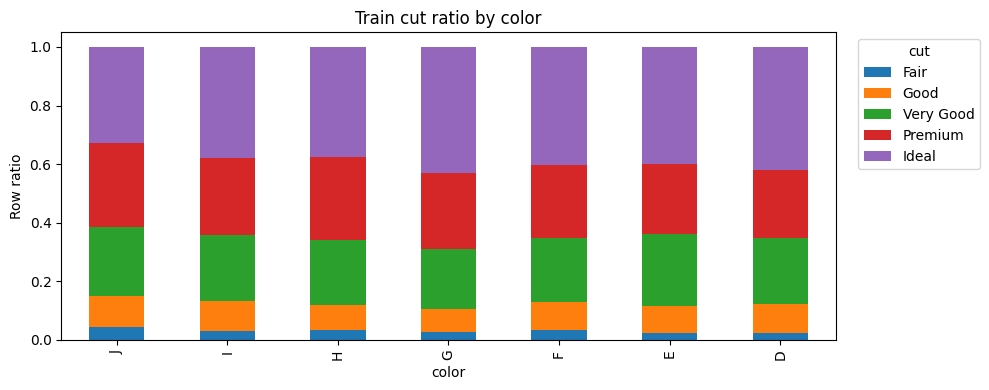


--- Train clarity x cut count ---


cut,Fair,Good,Very Good,Premium,Ideal
clarity,,,,,
I1,126,52,51,120,87
SI2,284,645,1258,1800,1548
SI1,230,947,1897,2125,2546
VS2,164,578,1559,2015,3054
VS1,104,383,1063,1217,2141
VVS2,42,180,787,510,1585
VVS1,12,113,477,348,1249
IF,3,44,157,133,718


--- Train clarity x cut row ratio ---


cut,Fair,Good,Very Good,Premium,Ideal
clarity,,,,,
I1,0.288991,0.119266,0.116972,0.275229,0.199541
SI2,0.051310,0.116531,0.227281,0.325203,0.279675
SI1,0.029697,0.122272,0.244932,0.274371,0.328728
VS2,0.022252,0.078426,0.211533,0.273406,0.414383
VS1,0.021190,0.078036,0.216585,0.247963,0.436227
VVS2,0.013531,0.057990,0.253544,0.164304,0.510631
VVS1,0.005457,0.051387,0.216917,0.158254,0.567985
IF,0.002844,0.041706,0.148815,0.126066,0.680569


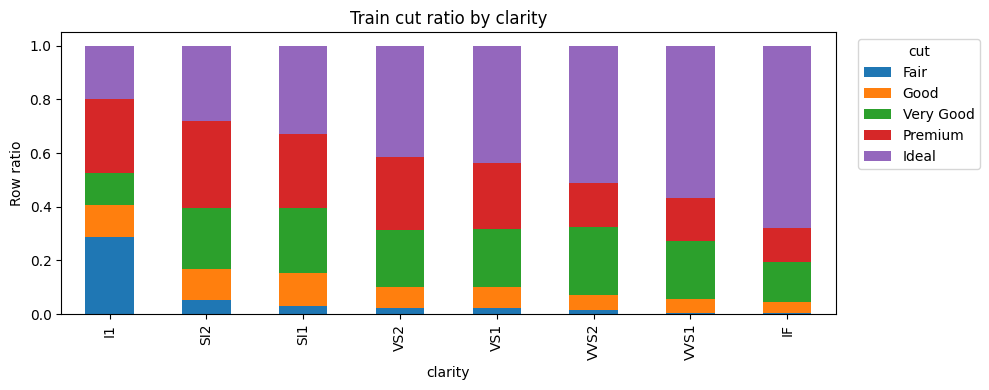

,feature,chi2,p_value,dof,cramers_v
0,clarity,2725.764739,0.000000e+00,28,0.144394
1,color,189.393494,1.162032e-27,24,0.035752



**범주형 해석.** 이 train split에서는 `clarity`가 `color`보다 cut과 더 강하게 관련되지만, 둘 다 핵심 geometry 신호보다는 약하다. 제공된 ordinal encoding은 등급 순서를 보존하므로 그대로 유지하고, hidden layer가 비선형 상호작용을 학습하도록 둔다.


In [12]:
print('=== C0-4. Train-only categorical association with cut ===')


def corrected_cramers_v(contingency):
    """Bias-corrected Cramer's V for a contingency table."""
    chi2, p_value, dof, _ = chi2_contingency(contingency)
    n = contingency.to_numpy().sum()
    r, k = contingency.shape

    phi2 = chi2 / n
    phi2_corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(k_corr - 1, r_corr - 1)

    v = np.sqrt(phi2_corr / denom) if denom > 0 else 0.0
    return chi2, p_value, dof, v


category_orders = {
    'color': color_order,
    'clarity': clarity_order,
}

categorical_rows = []

for col, category_order in category_orders.items():
    count_table = pd.crosstab(train_eda[col], train_eda['cut']).reindex(
        index=category_order,
        columns=cut_order,
        fill_value=0,
    )

    ratio_table = count_table.div(count_table.sum(axis=1), axis=0)

    chi2, p_value, dof, cramers_v = corrected_cramers_v(count_table)

    print(f'\n--- Train {col} x cut count ---')
    display(count_table)

    print(f'--- Train {col} x cut row ratio ---')
    display(ratio_table)

    ratio_table.plot(kind='bar', stacked=True, figsize=(10, 4))
    plt.title(f'Train cut ratio by {col}')
    plt.xlabel(col)
    plt.ylabel('Row ratio')
    plt.legend(title='cut', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    categorical_rows.append({
        'feature': col,
        'chi2': chi2,
        'p_value': p_value,
        'dof': dof,
        'cramers_v': cramers_v,
    })

categorical_train_result = (
    pd.DataFrame(categorical_rows)
    .sort_values('cramers_v', ascending=False)
    .reset_index(drop=True)
)

display(categorical_train_result)

display(Markdown("""
**범주형 해석.** 이 train split에서는 `clarity`가 `color`보다 cut과 더 강하게 관련되지만, 둘 다 핵심 geometry 신호보다는 약하다. 제공된 ordinal encoding은 등급 순서를 보존하므로 그대로 유지하고, hidden layer가 비선형 상호작용을 학습하도록 둔다.
"""))


=== C0-5. Redundancy and geometry anomaly checks ===


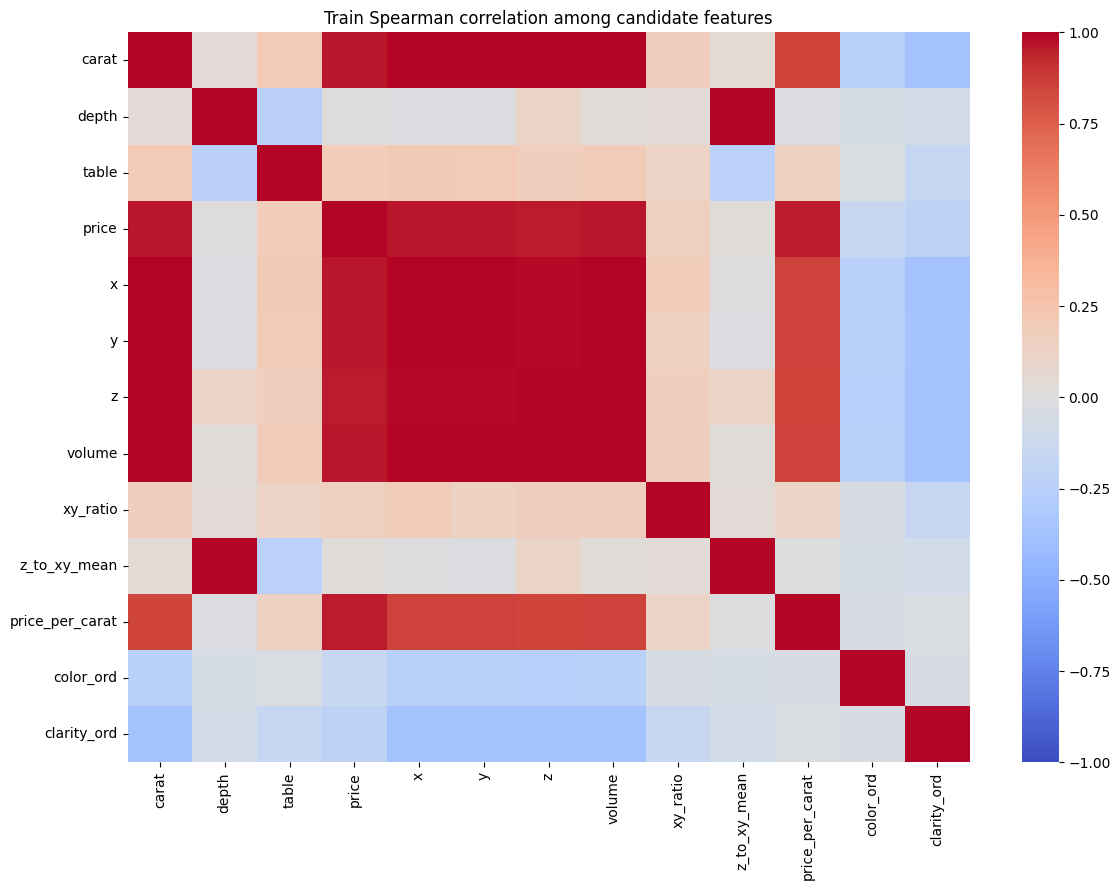

Top redundancy pairs:


,feature_1,feature_2,spearman_corr,abs_corr
0,carat,volume,0.998334,0.998334
1,y,volume,0.998108,0.998108
2,x,volume,0.998080,0.998080
3,x,y,0.997960,0.997960
4,depth,z_to_xy_mean,0.996767,0.996767
5,carat,x,0.996587,0.996587
6,carat,y,0.995922,0.995922
7,carat,z,0.994647,0.994647
8,z,volume,0.994260,0.994260
9,x,z,0.988335,0.988335


,feature,min,q01,median,q99,max,iqr_outlier_count,iqr_outlier_ratio
0,x,3.730000,4.010000,5.700000,8.340000,10.740000,12,0.000371
1,y,3.680000,4.040000,5.710000,8.320000,58.900000,12,0.000371
2,z,1.070000,2.480000,3.530000,5.150000,8.060000,14,0.000433
3,volume,31.707984,40.081566,114.907949,353.766008,3840.598060,781,0.024141
4,xy_ratio,0.137351,0.982729,0.995726,1.020185,1.615572,93,0.002875
5,z_to_xy_mean,0.161023,0.578758,0.618431,0.655905,1.006965,1639,0.050661



**모델링 해석.** size-price 축(`carat/x/y/z/volume/price`)은 매우 강하게 중복되어 있다. `depth`와 `z_to_xy_mean`도 거의 같은 proportion 신호로 볼 수 있다. B3 이후 mandatory feature를 추가하거나 제거하지 않고, Regularized 모델에서 L2, BatchNorm, Dropout, EarlyStopping이 이 중복성을 제어하는지 비교한다.


In [13]:
print('=== C0-5. Redundancy and geometry anomaly checks ===')

corr_cols = [
    'carat', 'depth', 'table', 'price', 'x', 'y', 'z',
    'volume', 'xy_ratio', 'z_to_xy_mean', 'price_per_carat',
    'color_ord', 'clarity_ord',
]

train_corr = train_eda[corr_cols].corr(method='spearman')

plt.figure(figsize=(12, 9))
sns.heatmap(train_corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Train Spearman correlation among candidate features')
plt.tight_layout()
plt.show()

pair_rows = []

for i, col_1 in enumerate(corr_cols):
    for col_2 in corr_cols[i + 1:]:
        corr_value = train_corr.loc[col_1, col_2]
        pair_rows.append({
            'feature_1': col_1,
            'feature_2': col_2,
            'spearman_corr': corr_value,
            'abs_corr': abs(corr_value),
        })

high_corr_pairs = (
    pd.DataFrame(pair_rows)
    .sort_values('abs_corr', ascending=False)
    .reset_index(drop=True)
)

print('Top redundancy pairs:')
display(high_corr_pairs.head(20))

geometry_check_cols = ['x', 'y', 'z', 'volume', 'xy_ratio', 'z_to_xy_mean']

outlier_rows = []

for col in geometry_check_cols:
    q1 = train_eda[col].quantile(0.25)
    q3 = train_eda[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (train_eda[col] < lower) | (train_eda[col] > upper)

    outlier_rows.append({
        'feature': col,
        'min': train_eda[col].min(),
        'q01': train_eda[col].quantile(0.01),
        'median': train_eda[col].median(),
        'q99': train_eda[col].quantile(0.99),
        'max': train_eda[col].max(),
        'iqr_outlier_count': int(mask.sum()),
        'iqr_outlier_ratio': float(mask.mean()),
    })

geometry_outlier_summary = pd.DataFrame(outlier_rows)
display(geometry_outlier_summary)

display(Markdown("""
**모델링 해석.** size-price 축(`carat/x/y/z/volume/price`)은 매우 강하게 중복되어 있다. `depth`와 `z_to_xy_mean`도 거의 같은 proportion 신호로 볼 수 있다. B3 이후 mandatory feature를 추가하거나 제거하지 않고, Regularized 모델에서 L2, BatchNorm, Dropout, EarlyStopping이 이 중복성을 제어하는지 비교한다.
"""))


=== C0-6. Validation sanity check without using test ===


,table,depth,xy_ratio,z_to_xy_mean,carat,volume,price
Fair,0.0,0.070044,0.074292,0.069540,0.000000,0.016979,0.072292
Good,0.0,0.000000,0.014587,0.004040,0.021194,0.041035,0.059571
Very Good,0.0,0.070044,0.003769,0.057809,0.000000,0.009734,0.006171
Premium,0.0,0.000000,0.000878,0.025174,0.254332,0.177121,0.096977
Ideal,0.0,0.000000,0.003921,0.014589,0.021194,0.014403,0.005919


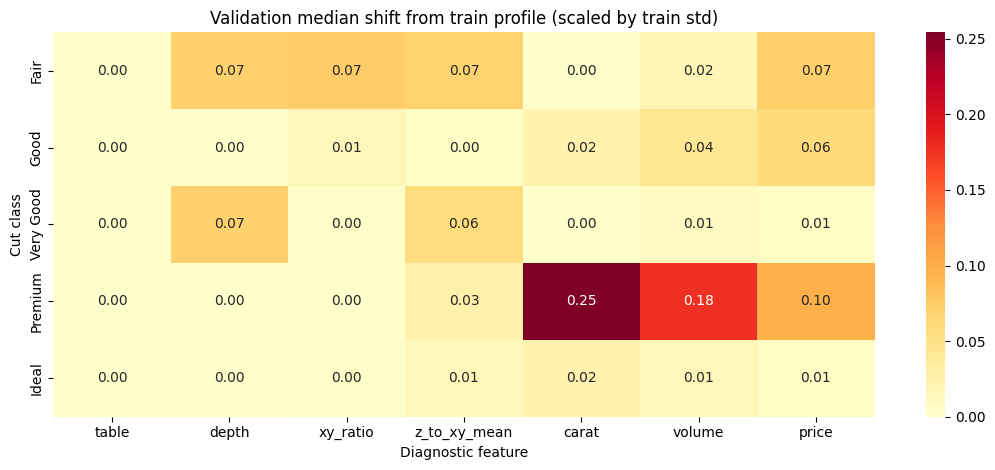


**관찰:** 주요 EDA feature에서 validation profile은 train profile과 크게 벗어나지 않는다. 가장 큰 scaled median shift는 `Premium` / `carat` = `0.254`이다.

**결론:** C0에서 validation은 split sanity check 용도로만 사용한다. 모델 선택은 C4에서 validation prediction으로 수행하고, test는 Part D 전까지 사용하지 않는다.


In [14]:
print('=== C0-6. Validation sanity check without using test ===')

sanity_cols = ['table', 'depth', 'xy_ratio', 'z_to_xy_mean', 'carat', 'volume', 'price']

train_profile = train_eda.groupby('cut_label', observed=False)[sanity_cols].median().reindex(class_ids)
val_profile = val_eda.groupby('cut_label', observed=False)[sanity_cols].median().reindex(class_ids)
profile_scale = train_eda[sanity_cols].std().replace(0, 1)

profile_shift = ((val_profile - train_profile) / profile_scale).abs()
profile_shift.index = cut_order

display(profile_shift)

plt.figure(figsize=(11, 4.8))
sns.heatmap(profile_shift, cmap='YlOrRd', annot=True, fmt='.2f')
plt.title('Validation median shift from train profile (scaled by train std)')
plt.xlabel('Diagnostic feature')
plt.ylabel('Cut class')
plt.tight_layout()
plt.show()

max_shift = profile_shift.stack().idxmax()
max_shift_value = profile_shift.stack().max()

display(Markdown(f"""
**관찰:** 주요 EDA feature에서 validation profile은 train profile과 크게 벗어나지 않는다. 가장 큰 scaled median shift는 `{max_shift[0]}` / `{max_shift[1]}` = `{max_shift_value:.3f}`이다.

**결론:** C0에서 validation은 split sanity check 용도로만 사용한다. 모델 선택은 C4에서 validation prediction으로 수행하고, test는 Part D 전까지 사용하지 않는다.
"""))


=== C0-7. Deep visual board from train-only EDA signals ===


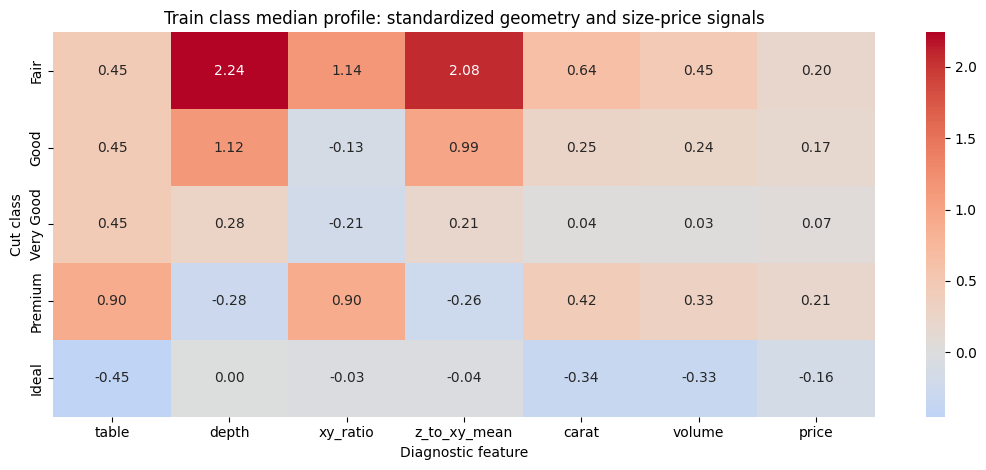

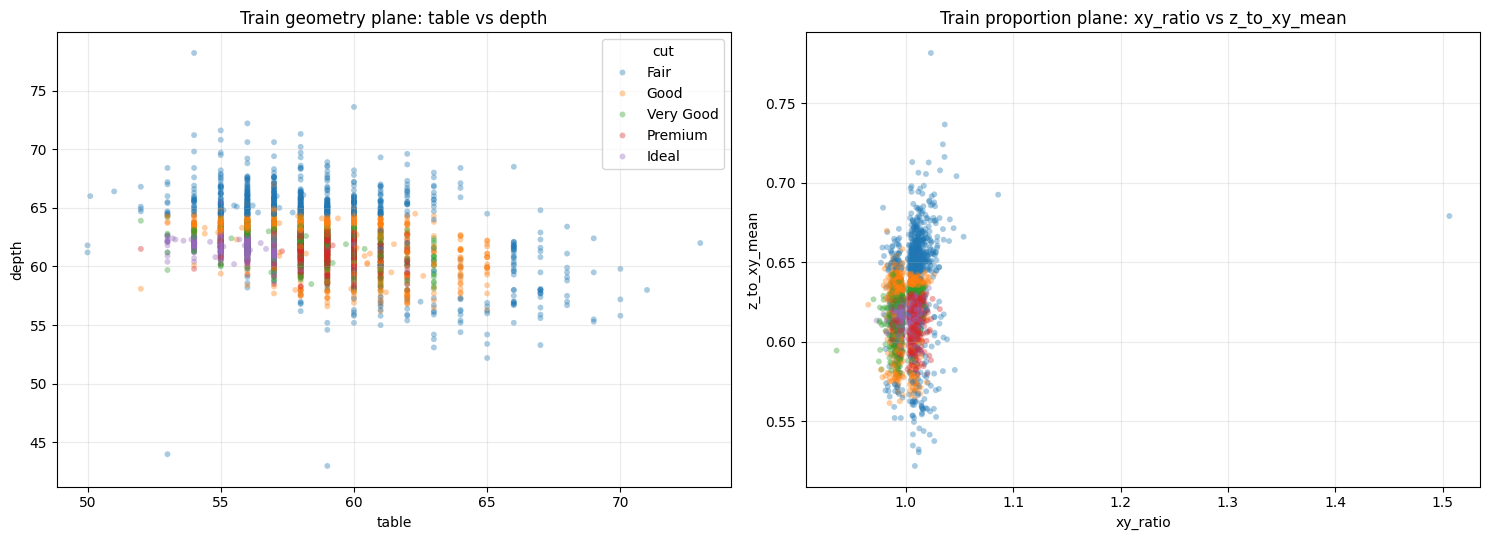

PCA explained variance ratio: [0.5743, 0.2091]


,PC1_loading,PC2_loading
carat,0.412924,0.026837
x,0.411976,-0.009238
z,0.410992,0.072610
volume,0.408514,-0.002156
y,0.405530,-0.035117
price,0.387069,0.006839
table,0.091375,-0.319760
xy_ratio,0.036474,0.091272
depth,0.003502,0.663310
z_to_xy_mean,-0.001620,0.664891


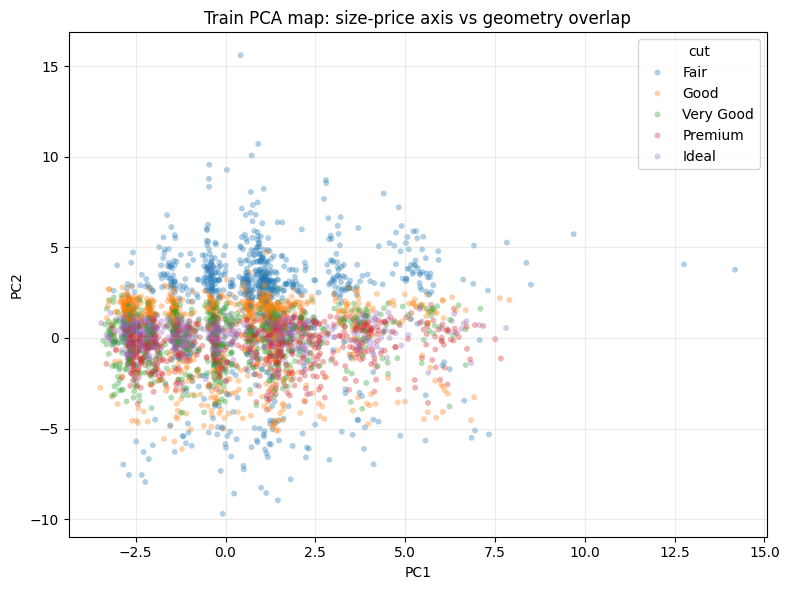


**관찰:** `Fair`는 support가 작지만 geometry profile이 상대적으로 극단적이어서 분리 가능성이 있다. 반면 `Very Good`, `Premium`, `Ideal`은 상위 품질 영역에서 geometry가 많이 겹친다.

**원인:** MLP는 geometry 신호와 강한 size-price 축을 동시에 본다. geometry가 국소적으로 애매하면 class prior와 중복된 size-price 정보가 중간 class를 더 큰 인접/상위 class 쪽으로 끌어갈 수 있다.

**한계:** 이 그림들은 train-only 진단이다. 모델 설계와 D4 해석 근거로만 사용하며, test를 보고 모델을 선택하지 않는다.

**결론:** 핵심 시각화 리스크는 단순한 인접 class 혼동이 아니라 상위 품질 영역의 geometry overlap이다. 특히 중간 class가 더 큰 `Ideal` 영역으로 흡수될 수 있다.


In [15]:
print('=== C0-7. Deep visual board from train-only EDA signals ===')

from sklearn.decomposition import PCA


def stratified_eda_sample(frame, max_per_class=700):
    parts = []
    for class_id in class_ids:
        part = frame.loc[frame['cut_label'] == class_id]
        n = min(max_per_class, len(part))
        parts.append(part.sample(n=n, random_state=SEED))
    return pd.concat(parts, axis=0).sample(frac=1.0, random_state=SEED)


plot_train = stratified_eda_sample(train_eda, max_per_class=700)

deep_profile_cols = ['table', 'depth', 'xy_ratio', 'z_to_xy_mean', 'carat', 'volume', 'price']
class_medians = train_eda.groupby('cut_label', observed=False)[deep_profile_cols].median().reindex(class_ids)
class_medians.index = cut_order

class_z = (class_medians - train_eda[deep_profile_cols].median()) / train_eda[deep_profile_cols].std().replace(0, 1)

plt.figure(figsize=(11, 4.8))
sns.heatmap(class_z, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Train class median profile: standardized geometry and size-price signals')
plt.xlabel('Diagnostic feature')
plt.ylabel('Cut class')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.scatterplot(
    data=plot_train,
    x='table',
    y='depth',
    hue='cut',
    hue_order=cut_order,
    alpha=0.38,
    s=18,
    linewidth=0,
    ax=axes[0],
)
axes[0].set_title('Train geometry plane: table vs depth')
axes[0].grid(alpha=0.25)

sns.scatterplot(
    data=plot_train,
    x='xy_ratio',
    y='z_to_xy_mean',
    hue='cut',
    hue_order=cut_order,
    alpha=0.38,
    s=18,
    linewidth=0,
    ax=axes[1],
)
axes[1].set_title('Train proportion plane: xy_ratio vs z_to_xy_mean')
axes[1].grid(alpha=0.25)
axes[1].legend_.remove()

plt.tight_layout()
plt.show()

pca_cols = ['carat', 'x', 'y', 'z', 'volume', 'price', 'table', 'depth', 'xy_ratio', 'z_to_xy_mean']
pca_scaler = StandardScaler()
pca_values = pca_scaler.fit_transform(train_eda[pca_cols])
pca = PCA(n_components=2)
pca_scores = pca.fit_transform(pca_values)

pca_frame = train_eda[['cut', 'cut_label']].copy()
pca_frame['PC1'] = pca_scores[:, 0]
pca_frame['PC2'] = pca_scores[:, 1]
pca_plot = stratified_eda_sample(pca_frame, max_per_class=700)

pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_cols,
    columns=['PC1_loading', 'PC2_loading'],
)
pca_loadings['abs_PC1'] = pca_loadings['PC1_loading'].abs()
pca_loadings['abs_PC2'] = pca_loadings['PC2_loading'].abs()

print('PCA explained variance ratio:', np.round(pca.explained_variance_ratio_, 4).tolist())
display(pca_loadings.sort_values('abs_PC1', ascending=False).drop(columns=['abs_PC1', 'abs_PC2']))

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_plot,
    x='PC1',
    y='PC2',
    hue='cut',
    hue_order=cut_order,
    alpha=0.35,
    s=18,
    linewidth=0,
)
plt.title('Train PCA map: size-price axis vs geometry overlap')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

display(Markdown("""
**관찰:** `Fair`는 support가 작지만 geometry profile이 상대적으로 극단적이어서 분리 가능성이 있다. 반면 `Very Good`, `Premium`, `Ideal`은 상위 품질 영역에서 geometry가 많이 겹친다.

**원인:** MLP는 geometry 신호와 강한 size-price 축을 동시에 본다. geometry가 국소적으로 애매하면 class prior와 중복된 size-price 정보가 중간 class를 더 큰 인접/상위 class 쪽으로 끌어갈 수 있다.

**한계:** 이 그림들은 train-only 진단이다. 모델 설계와 D4 해석 근거로만 사용하며, test를 보고 모델을 선택하지 않는다.

**결론:** 핵심 시각화 리스크는 단순한 인접 class 혼동이 아니라 상위 품질 영역의 geometry overlap이다. 특히 중간 class가 더 큰 `Ideal` 영역으로 흡수될 수 있다.
"""))


In [16]:
print('=== C0-8. Shared model/evaluation utilities ===')


def reset_seed():
    np.random.seed(SEED)
    keras.utils.set_random_seed(SEED)


def classification_metrics(y_true, y_pred):
    """Common metrics for imbalanced ordinal multiclass classification."""
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'ordinal_mae': np.mean(np.abs(y_true - y_pred)),
    }


def predict_class(model, X_data):
    probability = model.predict(X_data, verbose=0)
    prediction = np.argmax(probability, axis=1)
    return probability, prediction


def display_history_end(model_name, history):
    last_idx = len(history.history['loss']) - 1

    row = {
        'model': model_name,
        'trained_epochs': len(history.history['loss']),
        'last_train_loss': history.history['loss'][last_idx],
        'last_val_loss': history.history['val_loss'][last_idx],
        'last_train_accuracy': history.history['accuracy'][last_idx],
        'last_val_accuracy': history.history['val_accuracy'][last_idx],
    }

    display(pd.DataFrame([row]))
    return row


print('input_dim :', X_train.shape[1])
print('num_classes:', len(cut_order))
print('X_train / X_val / X_test:', X_train.shape, X_val.shape, X_test.shape)


=== C0-8. Shared model/evaluation utilities ===
input_dim : 9
num_classes: 5
X_train / X_val / X_test: (32352, 9) (10784, 9) (10784, 9)


---

## C1. Baseline 분류 모델 (6점)

**요구사항**:
- 다중분류 모델 (Dense 3개층 이상)
- 출력층: `Dense(5, activation='softmax')`
- Loss: `sparse_categorical_crossentropy` (타겟이 int이므로)
- Metric: `accuracy`
- epochs=30, batch_size=64

**필수 출력**:
- 모델 구조 (`.summary()`)
- 최종 Train Accuracy, Val Accuracy


In [17]:
# C1. Baseline 분류 모델
print(' === C1. Baseline 분류 모델 ===')

input_dim = X_train.shape[1]
num_classes = len(cut_order)


def build_baseline_model(input_dim, num_classes=5):
    model = Sequential(name='baseline_classifier')
    model.add(keras.Input(shape=(input_dim,)))
    model.add(Dense(128, activation='relu', name='dense_128'))
    model.add(Dense(64, activation='relu', name='dense_64'))
    model.add(Dense(32, activation='relu', name='dense_32'))
    model.add(Dense(num_classes, activation='softmax', name='cut_probability'))
    return model


keras.backend.clear_session()
reset_seed()

baseline_model = build_baseline_model(input_dim, num_classes)

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

baseline_model.summary()

history_baseline = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    verbose=0,
)

baseline_train_eval = baseline_model.evaluate(
    X_train,
    y_train,
    verbose=0,
    return_dict=True,
)

baseline_val_eval = baseline_model.evaluate(
    X_val,
    y_val,
    verbose=0,
    return_dict=True,
)

print('\n=== C1 최종 성능 ===')
print(f"Final Train Accuracy: {baseline_train_eval['accuracy']:.4f}")
print(f"Final Val Accuracy  : {baseline_val_eval['accuracy']:.4f}")

baseline_history_end = display_history_end('Baseline', history_baseline)

 === C1. Baseline 분류 모델 ===


Model: "baseline_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_128 (Dense)               │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cut_probability (Dense)         │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,781 (46.02 KB)

 Trainable params: 11,781 (46.02 KB)

 Non-trainable params: 0 (0.00 B)


=== C1 최종 성능 ===
Final Train Accuracy: 0.8008
Final Val Accuracy  : 0.7884


,model,trained_epochs,last_train_loss,last_val_loss,last_train_accuracy,last_val_accuracy
0,Baseline,30,0.512972,0.54091,0.794912,0.78839


## C2. Regularized 분류 모델 (6점)

**요구사항**: 다음을 *모두* 적용
- L2 regularization (모든 Dense 층, λ=0.001)
- BatchNormalization (`Dense → BN → Activation` 순서)
- Dropout(0.3)
- EarlyStopping (patience=10, restore_best_weights=True)
- epochs=100 (EarlyStopping이 조기 종료하므로 충분히 크게 설정)

**필수 출력**:
- 최종 Train Accuracy, Val Accuracy
- 실제 학습된 epoch 수


In [18]:
# C2. Regularized 분류 모델
print(' === C2. Regularized 분류 모델 ===')


def build_regularized_model(input_dim, num_classes=5):
    model = Sequential(name='regularized_classifier')
    model.add(keras.Input(shape=(input_dim,)))

    # Dense → BatchNormalization → Activation → Dropout
    model.add(Dense(
        128,
        use_bias=False,
        kernel_regularizer=l2(0.001),
        name='dense_128_l2',
    ))
    model.add(BatchNormalization(name='bn_128'))
    model.add(Activation('relu', name='relu_128'))
    model.add(Dropout(0.3, name='dropout_128'))

    model.add(Dense(
        64,
        use_bias=False,
        kernel_regularizer=l2(0.001),
        name='dense_64_l2',
    ))
    model.add(BatchNormalization(name='bn_64'))
    model.add(Activation('relu', name='relu_64'))
    model.add(Dropout(0.3, name='dropout_64'))

    model.add(Dense(
        32,
        use_bias=False,
        kernel_regularizer=l2(0.001),
        name='dense_32_l2',
    ))
    model.add(BatchNormalization(name='bn_32'))
    model.add(Activation('relu', name='relu_32'))
    model.add(Dropout(0.3, name='dropout_32'))

    # 모든 Dense 층 L2 요구에 따라 output Dense에도 L2 적용
    model.add(Dense(
        num_classes,
        activation='softmax',
        kernel_regularizer=l2(0.001),
        name='cut_probability_l2',
    ))

    return model


keras.backend.clear_session()
reset_seed()

regularized_model = build_regularized_model(input_dim, num_classes)

regularized_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

regularized_model.summary()

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=0,
)

history_regularized = regularized_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=0,
)

regularized_train_eval = regularized_model.evaluate(
    X_train,
    y_train,
    verbose=0,
    return_dict=True,
)

regularized_val_eval = regularized_model.evaluate(
    X_val,
    y_val,
    verbose=0,
    return_dict=True,
)

regularized_best_epoch = int(np.argmin(history_regularized.history['val_loss']) + 1)

print('\n=== C2 최종 성능 — restore_best_weights 적용 후 ===')
print(f"Final Train Accuracy: {regularized_train_eval['accuracy']:.4f}")
print(f"Final Val Accuracy  : {regularized_val_eval['accuracy']:.4f}")
print(f"Actual trained epochs: {len(history_regularized.history['loss'])}")
print(f"Best val_loss epoch   : {regularized_best_epoch}")

regularized_history_end = display_history_end('Regularized', history_regularized)


 === C2. Regularized 분류 모델 ===


Model: "regularized_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_128_l2 (Dense)            │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_128 (BatchNormalization)     │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_128 (Activation)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_128 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64_l2 (Dense)             │ (None, 64)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_64 (BatchNormalization)      │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_64 (Activation)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32_l2 (Dense)             │ (None, 32)             │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_32 (BatchNormalization)      │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_32 (Activation)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cut_probability_l2 (Dense)      │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,453 (48.64 KB)

 Trainable params: 12,005 (46.89 KB)

 Non-trainable params: 448 (1.75 KB)


=== C2 최종 성능 — restore_best_weights 적용 후 ===
Final Train Accuracy: 0.7714
Final Val Accuracy  : 0.7728
Actual trained epochs: 48
Best val_loss epoch   : 38


,model,trained_epochs,last_train_loss,last_val_loss,last_train_accuracy,last_val_accuracy
0,Regularized,48,0.742204,0.646654,0.715999,0.767526


### C2 결과 해석 보완

Regularized 모델은 `Dropout(0.3)`, `L2(0.001)`, `BatchNormalization`, `EarlyStopping`을 모두 적용한 모델이다. 학습 history 마지막 줄의 train accuracy는 dropout이 켜진 training mode에서 측정되므로 낮게 보일 수 있다. 반면 `model.evaluate()`는 dropout이 꺼진 inference mode에서 수행되고, `restore_best_weights=True` 때문에 best validation loss 시점의 weight가 복원된 뒤 평가된다.

따라서 C2의 최종 해석은 history 마지막 줄만 보지 말고 `evaluate()` 결과를 기준으로 한다. 현재 실행에서는 Regularized가 validation accuracy와 macro-F1에서 Baseline보다 낮다. 이는 과적합 완화 효과보다 약한 underfitting 또는 과도한 regularization 효과가 더 크게 작동한 것으로 해석한다.


## C3. 학습 곡선 비교 (3점)

두 모델(Baseline, Regularized)의 **Validation Loss**와 **Validation Accuracy**를 각각 비교 시각화하시오.
(하나의 Figure에 서브플롯 2개 — 왼쪽: Validation Loss, 오른쪽: Validation Accuracy)

=== C3. Baseline vs Regularized learning curves ===


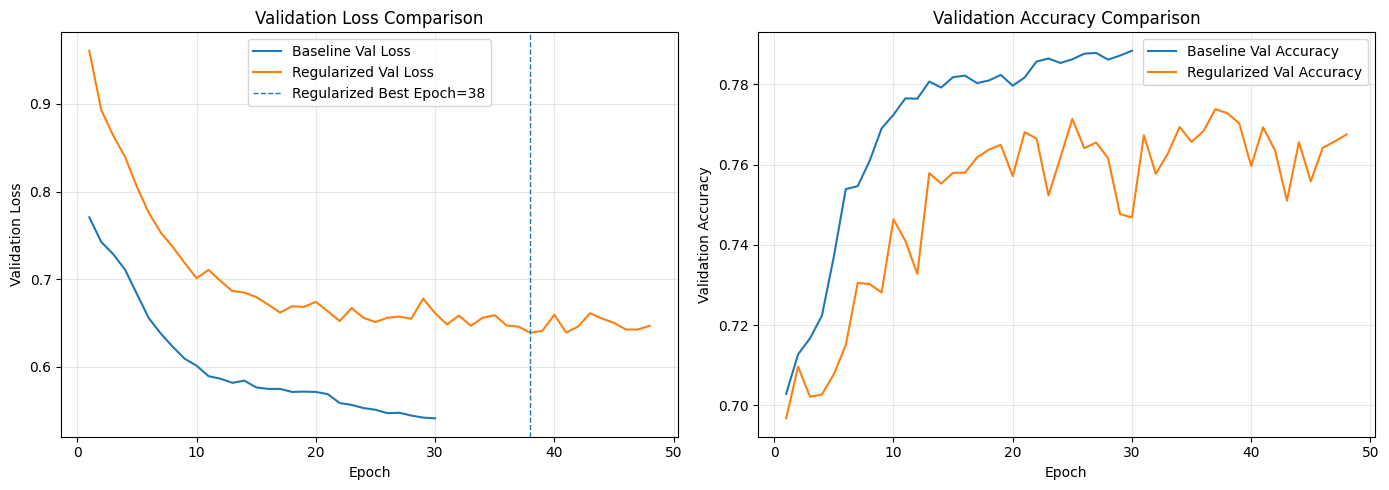

Note: Regularized val_loss includes the L2 penalty, so loss is not the only cross-model criterion.
=== C4. Validation prediction metrics before test access ===


,model,accuracy,macro_f1,weighted_f1,balanced_accuracy,ordinal_mae
0,Baseline,0.788390,0.772067,0.785114,0.762396,0.290616
1,Regularized,0.772812,0.743734,0.767299,0.721262,0.305545


Validation-selected model: Baseline


In [19]:
print('=== C3. Baseline vs Regularized learning curves ===')

baseline_epochs = np.arange(1, len(history_baseline.history['loss']) + 1)
regularized_epochs = np.arange(1, len(history_regularized.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    baseline_epochs,
    history_baseline.history['val_loss'],
    label='Baseline Val Loss',
)
axes[0].plot(
    regularized_epochs,
    history_regularized.history['val_loss'],
    label='Regularized Val Loss',
)
axes[0].axvline(
    regularized_best_epoch,
    linestyle='--',
    linewidth=1,
    label=f'Regularized Best Epoch={regularized_best_epoch}',
)
axes[0].set_title('Validation Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    baseline_epochs,
    history_baseline.history['val_accuracy'],
    label='Baseline Val Accuracy',
)
axes[1].plot(
    regularized_epochs,
    history_regularized.history['val_accuracy'],
    label='Regularized Val Accuracy',
)
axes[1].set_title('Validation Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Note: Regularized val_loss includes the L2 penalty, so loss is not the only cross-model criterion.')

print('=== C4. Validation prediction metrics before test access ===')

baseline_val_probability, baseline_val_pred = predict_class(baseline_model, X_val)
regularized_val_probability, regularized_val_pred = predict_class(regularized_model, X_val)

baseline_val_metrics = classification_metrics(y_val, baseline_val_pred)
regularized_val_metrics = classification_metrics(y_val, regularized_val_pred)

val_comparison_df = pd.DataFrame([
    {'model': 'Baseline', **baseline_val_metrics},
    {'model': 'Regularized', **regularized_val_metrics},
])

val_comparison_df = val_comparison_df.sort_values(
    ['macro_f1', 'accuracy', 'ordinal_mae'],
    ascending=[False, False, True],
).reset_index(drop=True)

display(val_comparison_df)

selected_model_name = val_comparison_df.loc[0, 'model']

selected_model = (
    baseline_model
    if selected_model_name == 'Baseline'
    else regularized_model
)

selected_val_pred = (
    baseline_val_pred
    if selected_model_name == 'Baseline'
    else regularized_val_pred
)

print(f'Validation-selected model: {selected_model_name}')


---
# Part D. 혼동 행렬 + 클래스별 성능 분석 (10점)

## D1. Test 예측 및 정확도 (3점)

**요구사항**:
- 두 모델 모두 X_test로 예측
- `predict()` 결과를 `argmax`로 클래스 변환
- 두 모델의 Test Accuracy 출력 및 비교


In [20]:
print('=== D1. Test prediction and accuracy comparison - first test access ===')

baseline_test_probability, baseline_test_pred = predict_class(baseline_model, X_test)
regularized_test_probability, regularized_test_pred = predict_class(regularized_model, X_test)

assert np.allclose(baseline_test_probability.sum(axis=1), 1.0, atol=1e-5)
assert np.allclose(regularized_test_probability.sum(axis=1), 1.0, atol=1e-5)

baseline_test_metrics = classification_metrics(y_test, baseline_test_pred)
regularized_test_metrics = classification_metrics(y_test, regularized_test_pred)

test_comparison_df = pd.DataFrame([
    {'model': 'Baseline', **baseline_test_metrics},
    {'model': 'Regularized', **regularized_test_metrics},
])

display(test_comparison_df)

print(f"Baseline Test Accuracy   : {baseline_test_metrics['accuracy']:.4f}")
print(f"Regularized Test Accuracy: {regularized_test_metrics['accuracy']:.4f}")
print(f"C4 pre-selected model     : {selected_model_name}")
print('Test is used only for final generalization reporting, not for retroactive model selection.')

=== D1. Test prediction and accuracy comparison - first test access ===


,model,accuracy,macro_f1,weighted_f1,balanced_accuracy,ordinal_mae
0,Baseline,0.783568,0.769408,0.779274,0.756928,0.296643
1,Regularized,0.763631,0.733882,0.756994,0.710900,0.318157


Baseline Test Accuracy   : 0.7836
Regularized Test Accuracy: 0.7636
C4 pre-selected model     : Baseline
Test is used only for final generalization reporting, not for retroactive model selection.


## D2. 혼동 행렬 시각화 (2점)

**요구사항**:
- 두 모델의 혼동 행렬을 *seaborn heatmap*으로 시각화
- 행/열 라벨에 클래스 이름 표시 (Fair, Good, Very Good, Premium, Ideal)
- 제목에 각 모델의 Test Accuracy 표시


=== D2. Confusion matrices for both models ===


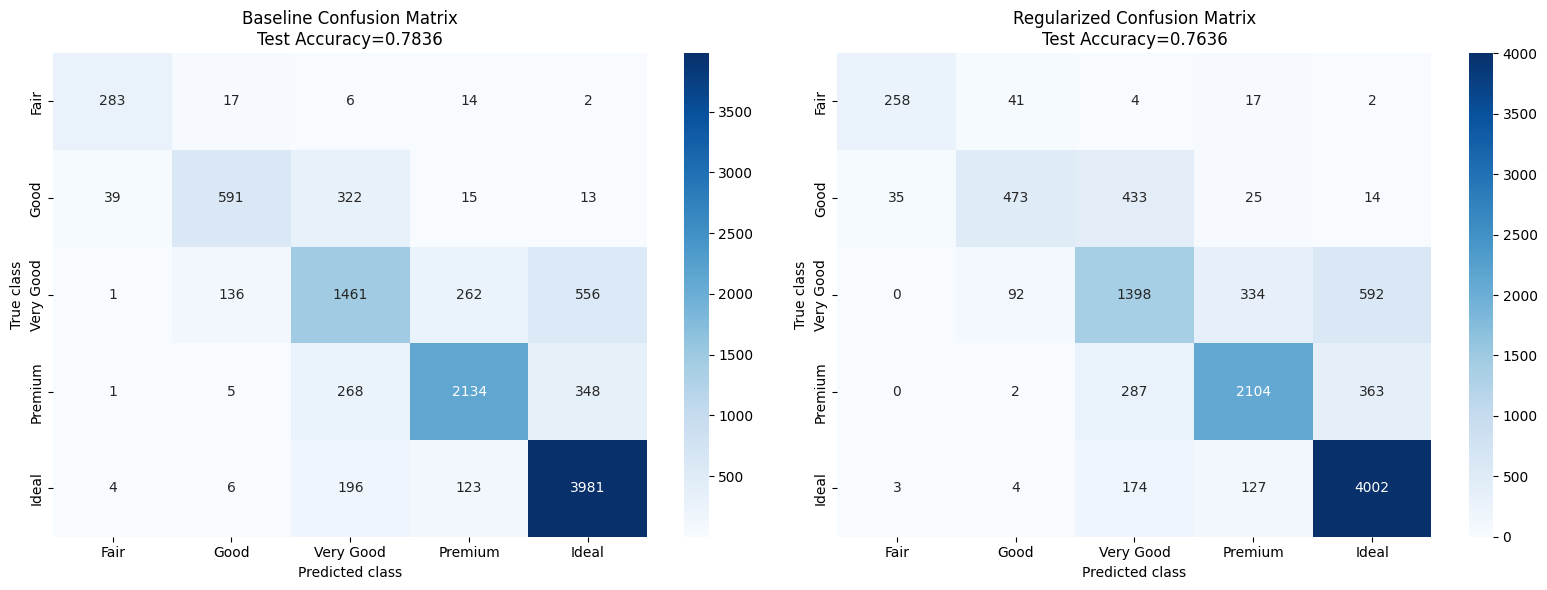

In [21]:
# D2. 혼동 행렬 시각화
print('=== D2. Confusion matrices for both models ===')

cm_baseline = confusion_matrix(y_test, baseline_test_pred, labels=class_ids)
cm_regularized = confusion_matrix(y_test, regularized_test_pred, labels=class_ids)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    cm_baseline,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=cut_order,
    yticklabels=cut_order,
    ax=axes[0],
)
axes[0].set_title(
    f"Baseline Confusion Matrix\nTest Accuracy={baseline_test_metrics['accuracy']:.4f}"
)
axes[0].set_xlabel('Predicted class')
axes[0].set_ylabel('True class')

sns.heatmap(
    cm_regularized,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=cut_order,
    yticklabels=cut_order,
    ax=axes[1],
)
axes[1].set_title(
    f"Regularized Confusion Matrix\nTest Accuracy={regularized_test_metrics['accuracy']:.4f}"
)
axes[1].set_xlabel('Predicted class')
axes[1].set_ylabel('True class')

plt.tight_layout()
plt.show()

## D3. 클래스별 정밀도/재현율/F1 출력 (2점)

`sklearn.metrics.classification_report` 사용하여 클래스별 성능 출력 (두 모델 모두).

In [22]:
print('=== D3. Per-class precision / recall / F1 ===')

print('\n[Baseline classification report]')
print(classification_report(
    y_test,
    baseline_test_pred,
    labels=class_ids,
    target_names=cut_order,
    digits=4,
    zero_division=0,
))

print('[Regularized classification report]')
print(classification_report(
    y_test,
    regularized_test_pred,
    labels=class_ids,
    target_names=cut_order,
    digits=4,
    zero_division=0,
))

baseline_report_dict = classification_report(
    y_test,
    baseline_test_pred,
    labels=class_ids,
    target_names=cut_order,
    output_dict=True,
    zero_division=0,
)

regularized_report_dict = classification_report(
    y_test,
    regularized_test_pred,
    labels=class_ids,
    target_names=cut_order,
    output_dict=True,
    zero_division=0,
)

baseline_report_df = pd.DataFrame(baseline_report_dict).T
regularized_report_df = pd.DataFrame(regularized_report_dict).T

print('Baseline report DataFrame:')
display(baseline_report_df)

print('Regularized report DataFrame:')
display(regularized_report_df)

=== D3. Per-class precision / recall / F1 ===

[Baseline classification report]
              precision    recall  f1-score   support

        Fair     0.8628    0.8789    0.8708       322
        Good     0.7828    0.6031    0.6813       980
   Very Good     0.6485    0.6047    0.6258      2416
     Premium     0.8375    0.7743    0.8047      2756
       Ideal     0.8124    0.9237    0.8645      4310

    accuracy                         0.7836     10784
   macro avg     0.7888    0.7569    0.7694     10784
weighted avg     0.7809    0.7836    0.7793     10784

[Regularized classification report]
              precision    recall  f1-score   support

        Fair     0.8716    0.8012    0.8350       322
        Good     0.7729    0.4827    0.5942       980
   Very Good     0.6089    0.5786    0.5934      2416
     Premium     0.8071    0.7634    0.7846      2756
       Ideal     0.8047    0.9285    0.8622      4310

    accuracy                         0.7636     10784
   macro avg   

,precision,recall,f1-score,support
Fair,0.862805,0.878882,0.870769,322.000000
Good,0.782781,0.603061,0.681268,980.000000
Very Good,0.648469,0.604719,0.625830,2416.000000
Premium,0.837520,0.774311,0.804676,2756.000000
Ideal,0.812449,0.923666,0.864495,4310.000000
accuracy,0.783568,0.783568,0.783568,0.783568
macro avg,0.788805,0.756928,0.769408,10784.000000
weighted avg,0.780926,0.783568,0.779274,10784.000000


Regularized report DataFrame:


,precision,recall,f1-score,support
Fair,0.871622,0.801242,0.834951,322.000000
Good,0.772876,0.482653,0.594221,980.000000
Very Good,0.608885,0.578642,0.593379,2416.000000
Premium,0.807058,0.763425,0.784635,2756.000000
Ideal,0.804746,0.928538,0.862221,4310.000000
accuracy,0.763631,0.763631,0.763631,0.763631
macro avg,0.773037,0.710900,0.733882,10784.000000
weighted avg,0.760557,0.763631,0.756994,10784.000000


## D4. 클래스별 성능 분석 (3점)

선택 모델의 confusion matrix와 classification report를 보고 다음 질문에 답한다.

1. 어떤 class가 가장 잘 분류되었는가? 그 원인은 무엇인가?
2. 어떤 class가 가장 분류하기 어려운가? 그 원인은 무엇인가?
3. 어떤 class 쌍이 가장 자주 혼동되는가?

아래 분석은 C4에서 validation macro-F1 기준으로 모델을 선택한 뒤, Part D에서 실제 test metric을 사용해 생성한 제출용 분석이다.


In [23]:
print('=== D4. Per-class analysis for the selected model ===')

if selected_model_name == 'Baseline':
    analysis_test_pred = baseline_test_pred
    analysis_report_df = baseline_report_df
    analysis_cm = cm_baseline
    other_model_name = 'Regularized'
else:
    analysis_test_pred = regularized_test_pred
    analysis_report_df = regularized_report_df
    analysis_cm = cm_regularized
    other_model_name = 'Baseline'

class_report = analysis_report_df.loc[
    cut_order,
    ['precision', 'recall', 'f1-score', 'support']
].copy()

best_class = class_report['f1-score'].idxmax()
worst_class = class_report['f1-score'].idxmin()

pair_matrix = analysis_cm + analysis_cm.T
np.fill_diagonal(pair_matrix, 0)

pair_i, pair_j = np.unravel_index(np.argmax(pair_matrix), pair_matrix.shape)

if pair_i > pair_j:
    pair_i, pair_j = pair_j, pair_i

pair_class_1 = cut_order[pair_i]
pair_class_2 = cut_order[pair_j]
pair_distance = abs(pair_i - pair_j)

pair_total = int(analysis_cm[pair_i, pair_j] + analysis_cm[pair_j, pair_i])
pair_1_to_2 = int(analysis_cm[pair_i, pair_j])
pair_2_to_1 = int(analysis_cm[pair_j, pair_i])

if pair_distance == 1:
    pair_relation_text = '인접 등급 간 혼동'
else:
    pair_relation_text = f'{pair_distance}단계 떨어진 비인접 등급 간 혼동'

profile_cols = ['table', 'depth']
class_profile = train_meta.groupby('cut_label', observed=False)[profile_cols].median().reindex(class_ids)
profile_scale = train_meta[profile_cols].std().replace(0, 1)

worst_idx = cut_order.index(worst_class)

profile_distance = np.sqrt(
    (((class_profile - class_profile.loc[worst_idx]) / profile_scale) ** 2).sum(axis=1)
)

profile_distance.loc[worst_idx] = np.inf

nearest_profile_idx = int(profile_distance.idxmin())
nearest_profile_class = cut_order[nearest_profile_idx]

train_ratio_map = split_distribution.set_index('class_name')['train_ratio'].to_dict()

selected_macro_f1 = classification_metrics(y_test, analysis_test_pred)['macro_f1']

other_macro_f1 = (
    regularized_test_metrics['macro_f1']
    if selected_model_name == 'Baseline'
    else baseline_test_metrics['macro_f1']
)

analysis_markdown = f"""
### D4 제출용 분석

1. **가장 잘 분류된 class는 `{best_class}`이다.** 선택 모델 `{selected_model_name}`에서 precision은 `{class_report.loc[best_class, 'precision']:.4f}`, recall은 `{class_report.loc[best_class, 'recall']:.4f}`, F1은 `{class_report.loc[best_class, 'f1-score']:.4f}`이다. Train 비율은 `{train_ratio_map[best_class]:.2%}`이다. 이 결과를 단순히 support가 충분해서라고 설명하면 부정확하다. C0의 train-only 시각화에서 확인한 것처럼 `table`과 `depth` geometry가 일부 class를 상대적으로 분리해 주기 때문에, support가 작아도 성능이 높게 나올 수 있다.

2. **가장 분류가 어려운 class는 `{worst_class}`이다.** precision은 `{class_report.loc[worst_class, 'precision']:.4f}`, recall은 `{class_report.loc[worst_class, 'recall']:.4f}`, F1은 `{class_report.loc[worst_class, 'f1-score']:.4f}`이다. Train 비율은 `{train_ratio_map[worst_class]:.2%}`이다. Train-only `table`/`depth` 중앙값 profile에서는 `{nearest_profile_class}`와 가장 가깝다. 따라서 단순한 표본 부족보다는 geometry overlap 때문에 softmax 경계가 불안정해진 것으로 해석한다.

3. **가장 자주 혼동된 class 쌍은 `{pair_class_1}`-`{pair_class_2}`이다.** 양방향 off-diagonal 합은 `{pair_total}`건이며, `{pair_class_1} -> {pair_class_2}`는 `{pair_1_to_2}`건, `{pair_class_2} -> {pair_class_1}`는 `{pair_2_to_1}`건이다. 이 쌍은 label 기준으로 `{pair_relation_text}`이다. 중간 품질 class가 더 큰 상위 품질 영역으로 흡수되는 경우, 모델이 국소적인 `table`/`depth` 차이보다 class prior와 겹치는 geometry 영역을 더 강하게 반영했을 가능성이 있다.

4. **최종 mandatory 모델은 `{selected_model_name}`이다.** 선택 모델의 Test macro-F1은 `{selected_macro_f1:.4f}`이고, 비교 모델 `{other_model_name}`의 Test macro-F1은 `{other_macro_f1:.4f}`이다. 이 선택은 test 접근 전에 C4의 validation macro-F1 기준으로 이미 완료했으며, Part D의 test 결과는 최종 일반화 성능 보고용으로만 사용한다.
"""

display(Markdown(analysis_markdown))


=== D4. Per-class analysis for the selected model ===



### D4 제출용 분석

1. **가장 잘 분류된 class는 `Fair`이다.** 선택 모델 `Baseline`에서 precision은 `0.8628`, recall은 `0.8789`, F1은 `0.8708`이다. Train 비율은 `2.98%`이다. 이 결과를 단순히 support가 충분해서라고 설명하면 부정확하다. C0의 train-only 시각화에서 확인한 것처럼 `table`과 `depth` geometry가 일부 class를 상대적으로 분리해 주기 때문에, support가 작아도 성능이 높게 나올 수 있다.

2. **가장 분류가 어려운 class는 `Very Good`이다.** precision은 `0.6485`, recall은 `0.6047`, F1은 `0.6258`이다. Train 비율은 `22.41%`이다. Train-only `table`/`depth` 중앙값 profile에서는 `Premium`와 가장 가깝다. 따라서 단순한 표본 부족보다는 geometry overlap 때문에 softmax 경계가 불안정해진 것으로 해석한다.

3. **가장 자주 혼동된 class 쌍은 `Very Good`-`Ideal`이다.** 양방향 off-diagonal 합은 `752`건이며, `Very Good -> Ideal`는 `556`건, `Ideal -> Very Good`는 `196`건이다. 이 쌍은 label 기준으로 `2단계 떨어진 비인접 등급 간 혼동`이다. 중간 품질 class가 더 큰 상위 품질 영역으로 흡수되는 경우, 모델이 국소적인 `table`/`depth` 차이보다 class prior와 겹치는 geometry 영역을 더 강하게 반영했을 가능성이 있다.

4. **최종 mandatory 모델은 `Baseline`이다.** 선택 모델의 Test macro-F1은 `0.7694`이고, 비교 모델 `Regularized`의 Test macro-F1은 `0.7339`이다. 이 선택은 test 접근 전에 C4의 validation macro-F1 기준으로 이미 완료했으며, Part D의 test 결과는 최종 일반화 성능 보고용으로만 사용한다.


---
# Part E. 클래스 불균형 해결 (보너스)

> 이 Part는 **선택사항**입니다. 시도하지 않아도 100점 만점 가능.
> 시도해서 정확히 구현하면 최대 15점 추가 (총점 115점 가능).

## E1. class_weight 적용 모델

**요구사항**:
- `sklearn.utils.class_weight.compute_class_weight`로 균형 가중치 계산
- 위 가중치를 `model.fit(..., class_weight=...)`에 전달
- 동일 구조의 Regularized 모델로 학습

## E2. 결과 비교

**필수 출력**:
- class_weighted 모델의 Test Accuracy
- 분류 리포트 (D3와 비교)
- 마크다운으로 분석: macro F1이나 소수 클래스 recall이 어떻게 변했는가?


In [24]:
# E1. class_weight 적용 모델 (보너스)
print('=== E1. Class-weighted Regularized model ===')

weight_values = compute_class_weight(
    class_weight='balanced',
    classes=class_ids,
    y=y_train,
)

class_weight_bonus = {
    int(class_id): float(weight)
    for class_id, weight in zip(class_ids, weight_values)
}

print('class_weight:', class_weight_bonus)

keras.backend.clear_session()
reset_seed()

class_weighted_model = build_regularized_model(input_dim, num_classes)

class_weighted_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

weighted_early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=0,
)

history_class_weighted = class_weighted_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    class_weight=class_weight_bonus,
    callbacks=[weighted_early_stopping],
    verbose=0,
)

weighted_val_probability, weighted_val_pred = predict_class(class_weighted_model, X_val)
weighted_val_metrics = classification_metrics(y_val, weighted_val_pred)

print('Actual trained epochs:', len(history_class_weighted.history['loss']))

print('Validation metrics:')
display(pd.DataFrame([{'model': 'Class-weighted', **weighted_val_metrics}]))

print('The bonus model direction is checked on validation before test reporting.')

=== E1. Class-weighted Regularized model ===
class_weight: {0: 6.705077720207254, 1: 2.199320190346703, 2: 0.8925920816664368, 3: 0.7825834542815675, 4: 0.5004950495049505}


Actual trained epochs: 55
Validation metrics:


,model,accuracy,macro_f1,weighted_f1,balanced_accuracy,ordinal_mae
0,Class-weighted,0.75714,0.725022,0.747167,0.757162,0.324091


The bonus model direction is checked on validation before test reporting.


=== E2. Class-weighted test result comparison ===


Class-weighted Test Accuracy: 0.7507

[Class-weighted classification report]
              precision    recall  f1-score   support

        Fair     0.7345    0.8851    0.8028       322
        Good     0.5536    0.7531    0.6381       980
   Very Good     0.6530    0.4098    0.5036      2416
     Premium     0.7922    0.7747    0.7833      2756
       Ideal     0.8137    0.9160    0.8618      4310

    accuracy                         0.7507     10784
   macro avg     0.7094    0.7477    0.7179     10784
weighted avg     0.7462    0.7507    0.7394     10784



,model,accuracy,macro_f1,weighted_f1,balanced_accuracy,ordinal_mae
0,Baseline,0.783568,0.769408,0.779274,0.756928,0.296643
1,Regularized,0.763631,0.733882,0.756994,0.710900,0.318157
2,Class-weighted,0.750742,0.717935,0.739412,0.747721,0.331973


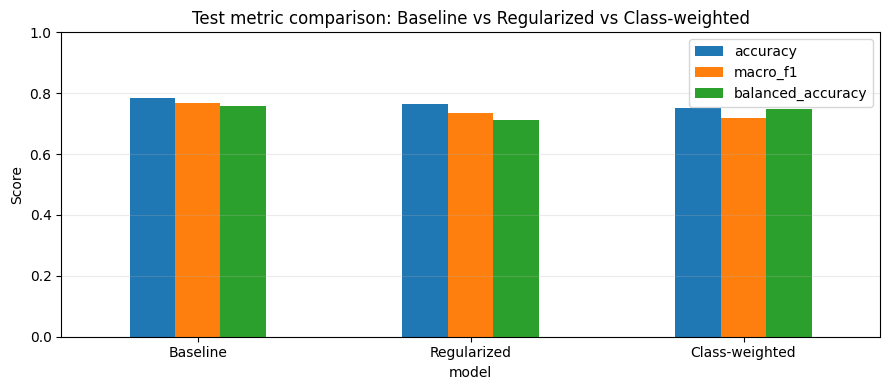

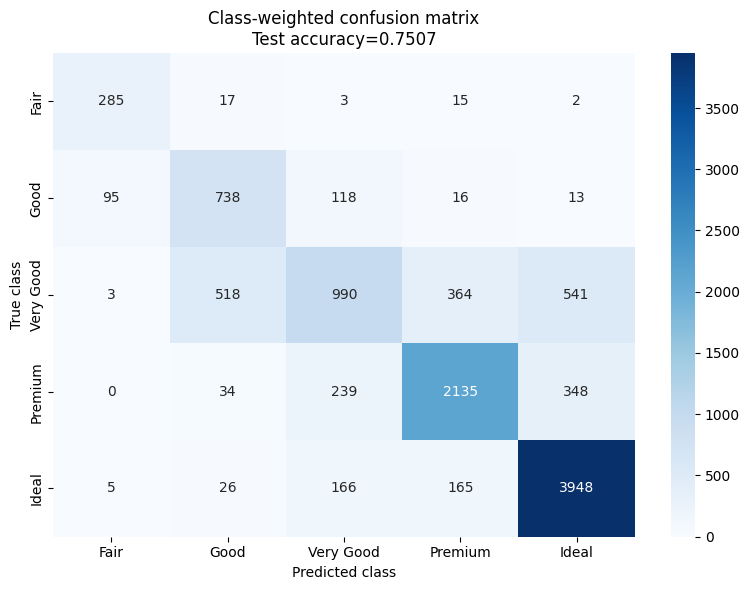

,baseline_recall,regularized_recall,class_weighted_recall,weighted_vs_regularized,weighted_vs_baseline
Fair,0.878882,0.801242,0.885093,0.083851,0.006211
Good,0.603061,0.482653,0.753061,0.270408,0.150000


,Baseline recall,Regularized recall,Class-weighted recall,Baseline F1,Regularized F1,Class-weighted F1
Fair,0.878882,0.801242,0.885093,0.870769,0.834951,0.802817
Good,0.603061,0.482653,0.753061,0.681268,0.594221,0.638132
Very Good,0.604719,0.578642,0.409768,0.625830,0.593379,0.503561
Premium,0.774311,0.763425,0.774673,0.804676,0.784635,0.783343
Ideal,0.923666,0.928538,0.916009,0.864495,0.862221,0.861821


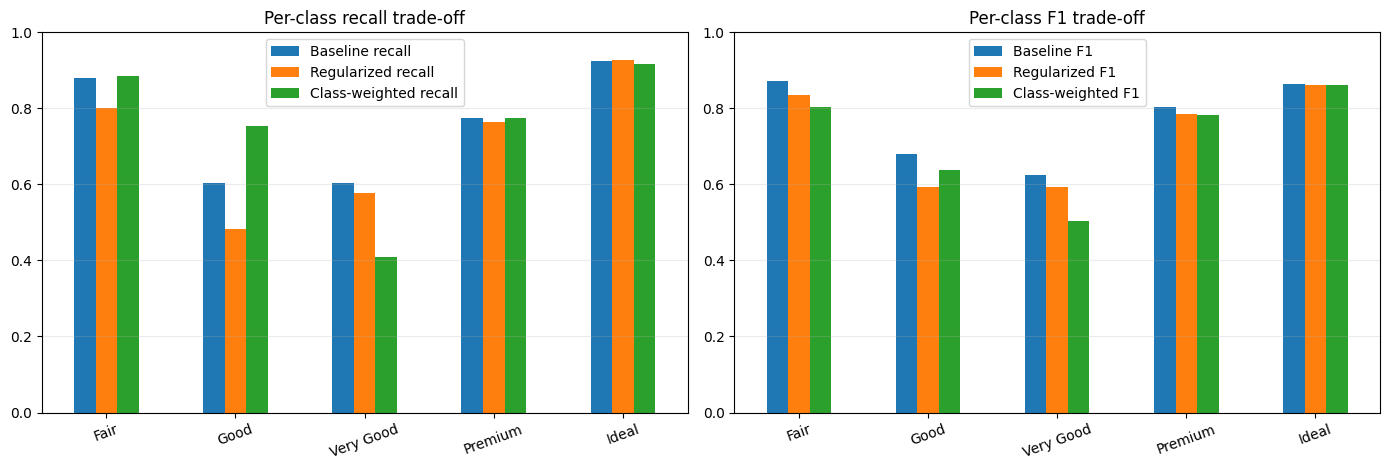


### Part E 결과 분석

Regularized와 비교하면 class_weight 적용 모델의 Test macro-F1 변화는 `-0.0159`, accuracy 변화는 `-0.0129`이다. Fair recall 변화는 `+0.0839`, Good recall 변화는 `+0.2704`이다.

Baseline과 비교하면 class_weight 적용 모델의 Test macro-F1 변화는 `-0.0515`, accuracy 변화는 `-0.0328`이다.

이 결과는 최종 모델 개선이 아니라 trade-off로 해석해야 한다. `class_weight`는 decision boundary를 소수 class 쪽으로 이동시켜 Regularized 대비 Fair/Good recall을 개선했지만, 현재 실행에서는 전체 accuracy와 macro-F1을 낮췄다. 따라서 Part E는 소수 class recall 개선을 보여주는 보조 실험으로 보고, 최종 mandatory 모델은 validation 기준으로 선택된 Baseline으로 유지한다.


In [25]:
# E2. Compare class_weighted results with Baseline and Regularized.
print('=== E2. Class-weighted test result comparison ===')

weighted_test_probability, weighted_test_pred = predict_class(class_weighted_model, X_test)
weighted_test_metrics = classification_metrics(y_test, weighted_test_pred)

print(f"Class-weighted Test Accuracy: {weighted_test_metrics['accuracy']:.4f}")

print('\n[Class-weighted classification report]')
print(classification_report(
    y_test,
    weighted_test_pred,
    labels=class_ids,
    target_names=cut_order,
    digits=4,
    zero_division=0,
))

weighted_report_dict = classification_report(
    y_test,
    weighted_test_pred,
    labels=class_ids,
    target_names=cut_order,
    output_dict=True,
    zero_division=0,
)

weighted_report_df = pd.DataFrame(weighted_report_dict).T

bonus_comparison_df = pd.DataFrame([
    {'model': 'Baseline', **baseline_test_metrics},
    {'model': 'Regularized', **regularized_test_metrics},
    {'model': 'Class-weighted', **weighted_test_metrics},
])

display(bonus_comparison_df)

metric_plot_df = bonus_comparison_df.set_index('model')[['accuracy', 'macro_f1', 'balanced_accuracy']]
metric_plot_df.plot(kind='bar', figsize=(9, 4), rot=0)
plt.title('Test metric comparison: Baseline vs Regularized vs Class-weighted')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.grid(alpha=0.25, axis='y')
plt.tight_layout()
plt.show()

cm_weighted = confusion_matrix(y_test, weighted_test_pred, labels=class_ids)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_weighted,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=cut_order,
    yticklabels=cut_order,
)
plt.title(
    f"Class-weighted confusion matrix\nTest accuracy={weighted_test_metrics['accuracy']:.4f}"
)
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.tight_layout()
plt.show()

minority_classes = ['Fair', 'Good']

minority_compare = pd.DataFrame({
    'baseline_recall': baseline_report_df.loc[minority_classes, 'recall'],
    'regularized_recall': regularized_report_df.loc[minority_classes, 'recall'],
    'class_weighted_recall': weighted_report_df.loc[minority_classes, 'recall'],
})

minority_compare['weighted_vs_regularized'] = (
    minority_compare['class_weighted_recall']
    - minority_compare['regularized_recall']
)

minority_compare['weighted_vs_baseline'] = (
    minority_compare['class_weighted_recall']
    - minority_compare['baseline_recall']
)

display(minority_compare)

per_class_compare = pd.DataFrame({
    'Baseline recall': baseline_report_df.loc[cut_order, 'recall'],
    'Regularized recall': regularized_report_df.loc[cut_order, 'recall'],
    'Class-weighted recall': weighted_report_df.loc[cut_order, 'recall'],
    'Baseline F1': baseline_report_df.loc[cut_order, 'f1-score'],
    'Regularized F1': regularized_report_df.loc[cut_order, 'f1-score'],
    'Class-weighted F1': weighted_report_df.loc[cut_order, 'f1-score'],
})

display(per_class_compare)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
per_class_compare[['Baseline recall', 'Regularized recall', 'Class-weighted recall']].plot(
    kind='bar',
    ax=axes[0],
    rot=20,
)
axes[0].set_title('Per-class recall trade-off')
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.25, axis='y')

per_class_compare[['Baseline F1', 'Regularized F1', 'Class-weighted F1']].plot(
    kind='bar',
    ax=axes[1],
    rot=20,
)
axes[1].set_title('Per-class F1 trade-off')
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.show()

macro_change_vs_regularized = (
    weighted_test_metrics['macro_f1']
    - regularized_test_metrics['macro_f1']
)

accuracy_change_vs_regularized = (
    weighted_test_metrics['accuracy']
    - regularized_test_metrics['accuracy']
)

macro_change_vs_baseline = (
    weighted_test_metrics['macro_f1']
    - baseline_test_metrics['macro_f1']
)

accuracy_change_vs_baseline = (
    weighted_test_metrics['accuracy']
    - baseline_test_metrics['accuracy']
)

bonus_markdown = f"""
### Part E 결과 분석

Regularized와 비교하면 class_weight 적용 모델의 Test macro-F1 변화는 `{macro_change_vs_regularized:+.4f}`, accuracy 변화는 `{accuracy_change_vs_regularized:+.4f}`이다. Fair recall 변화는 `{minority_compare.loc['Fair', 'weighted_vs_regularized']:+.4f}`, Good recall 변화는 `{minority_compare.loc['Good', 'weighted_vs_regularized']:+.4f}`이다.

Baseline과 비교하면 class_weight 적용 모델의 Test macro-F1 변화는 `{macro_change_vs_baseline:+.4f}`, accuracy 변화는 `{accuracy_change_vs_baseline:+.4f}`이다.

이 결과는 최종 모델 개선이 아니라 trade-off로 해석해야 한다. `class_weight`는 decision boundary를 소수 class 쪽으로 이동시켜 Regularized 대비 Fair/Good recall을 개선했지만, 현재 실행에서는 전체 accuracy와 macro-F1을 낮췄다. 따라서 Part E는 소수 class recall 개선을 보여주는 보조 실험으로 보고, 최종 mandatory 모델은 validation 기준으로 선택된 Baseline으로 유지한다.
"""

display(Markdown(bonus_markdown))


# 최종 제출 결론

이 문제는 diamond `cut`을 예측하는 5-class ordinal multiclass classification 문제다. C0는 제공 split을 보존한 상태에서 수행했다. EDA는 train 기준으로 진행했고, validation은 sanity check와 모델 선택에만 사용했으며, test는 Part D에서 처음 열었다.

Train-only EDA에서는 `table`, `depth`, `xy_ratio`, `z_to_xy_mean`이 cut과 관련된 geometry/proportion 신호로 확인되었다. 또한 `carat`, `x`, `y`, `z`, `volume`, `price`는 강한 size-price 중복 축을 형성했다. `Fair`와 `Good`은 소수 class이므로 모델 선택에는 validation macro-F1을 우선 사용하고, accuracy, balanced accuracy, ordinal MAE를 보조 지표로 함께 확인했다.

최종 mandatory 모델은 **Baseline**이다. Baseline은 test 접근 전 validation accuracy, validation macro-F1, ordinal MAE 기준에서 Regularized보다 좋았다. Part D의 test 평가에서도 Baseline이 accuracy, macro-F1, ordinal MAE 기준으로 더 안정적이었다. Regularized 모델은 L2, BatchNorm, Dropout, EarlyStopping 요구사항을 모두 충족하지만, 현재 데이터에서는 과적합 완화보다 약한 underfitting 또는 과도한 regularization 효과가 더 크게 작동했다.

Confusion analysis에서는 `Fair`가 소수 class임에도 geometry가 상대적으로 분리되어 좋은 성능을 보였다. 반면 `Very Good`, `Premium`, `Ideal`이 겹치는 상위 품질 영역은 분류가 어렵다. 가장 큰 혼동이 `Very Good`-`Ideal`처럼 비인접 쌍으로 나타날 수 있으므로, 이를 단순한 인접 등급 혼동이라고 설명하면 안 된다.

Bonus class_weight 모델은 Regularized 대비 `Fair`와 `Good` recall을 개선했지만, overall accuracy와 macro-F1은 낮아졌다. 따라서 class_weight는 소수 class recall 개선의 trade-off를 보여주는 보조 실험으로 해석하고, 최종 모델로는 Baseline을 유지한다.


---

# 제출 전 체크리스트

- [ ] `STUDENT_ID`가 본인 학번에 맞게 설정되어 있는가?
- [ ] Restart Kernel -> Run All 실행 시 traceback 없이 끝나는가?
- [ ] A/B 제공 코드를 수정하지 않았는가?
- [ ] C0가 train-only EDA와 validation-only sanity check 원칙을 지키는가?
- [ ] C4에서 test 접근 전에 모델 선택이 끝나는가?
- [ ] D4에서 `Very Good`-`Ideal`을 인접 등급이라고 잘못 설명하지 않는가?
- [ ] E2 비교표에 Baseline, Regularized, Class-weighted가 모두 포함되어 있는가?
